In [4]:
import pandas as pd

# Load FHFA data
hpi = pd.read_excel('/content/drive/My Drive/hpi_exp_state.xlsx')
hpi.head()

,state,yr,qtr,index_nsa,index_sa,note
0,AK,1991,1,100.00,100.00,Note: (External) County Records Data Comprise ...
1,AK,1991,2,99.80,99.63,Note: (External) County Records Data Comprise ...
2,AK,1991,3,101.41,100.93,Note: (External) County Records Data Comprise ...
3,AK,1991,4,100.20,101.06,Note: (External) County Records Data Comprise ...
4,AK,1992,1,102.11,102.10,Note: (External) County Records Data Comprise ...


In [6]:
import pandas as pd

# Filter for last 6 years
recent = hpi[hpi['yr'] >= 2018].copy()
recent = recent.sort_values(['state','yr','qtr'])

# Compute year-over-year % change (4 quarters)
recent['annual_appreciation'] = (
    recent.groupby('state')['index_sa'].pct_change(4) * 100
)

# Drop early NaNs (first 4 quarters per state)
recent = recent.dropna(subset=['annual_appreciation'])

# Average annual appreciation per state (last 6 years)
state_recent = (
    recent.groupby('state')['annual_appreciation']
    .mean()
    .reset_index()
    .rename(columns={'annual_appreciation': 'avg_appreciation_2018_2024'})
)

# Sort descending to see top states
state_recent = state_recent.sort_values('avg_appreciation_2018_2024', ascending=False)
print(state_recent.head(10))

   state  avg_appreciation_2018_2024
13    ID                   11.834087
21    ME                   10.985610
31    NJ                   10.553311
39    RI                   10.246298
42    TN                   10.164398
26    MT                   10.114394
30    NH                    9.961964
44    UT                    9.920581
3     AZ                    9.919607
9     FL                    9.850617


In [7]:
recent.head()

,state,yr,qtr,index_sa,annual_appreciation
112,AK,2019,1,263.73,1.387821
113,AK,2019,2,268.64,3.770087
114,AK,2019,3,268.77,3.852396
115,AK,2019,4,268.49,2.767358
116,AK,2020,1,273.92,3.863800


In [9]:
# ============================
# FHFA State-Level Appreciation (2018–2024)
# ============================

import pandas as pd

# --- Load FHFA Purchase-Only State file (Seasonally Adjusted) ---
# Example file path (update as needed)
fhfa_path = '/content/drive/My Drive/hpi_exp_state.xlsx'
hpi = pd.read_excel(fhfa_path)

# --- Normalize common column names ---
col_map = {c.lower(): c for c in hpi.columns}

def pick(*cands):
    """Pick first matching column name (case-insensitive)."""
    for c in cands:
        if c in hpi.columns:
            return c
    cl = [x.lower() for x in hpi.columns]
    for c in cands:
        if c.lower() in cl:
            return hpi.columns[cl.index(c.lower())]
    raise KeyError(f"None of {cands} found in FHFA columns: {list(hpi.columns)}")

STATE = pick("state","State")
YEAR  = pick("yr","Year","year")
QTR   = pick("qtr","Quarter","quarter")
IDXSA = pick("index_sa","Index (SA)","index (sa)")

# --- Keep relevant columns & clean ---
hpi = hpi[[STATE, YEAR, QTR, IDXSA]].rename(columns={
    STATE: "state", YEAR: "yr", QTR: "qtr", IDXSA: "index_sa"
})
hpi = hpi.dropna(subset=["state","yr","qtr","index_sa"]).sort_values(["state","yr","qtr"])

# --- Compute YoY (4-quarter) appreciation ---
hpi["annual_appreciation"] = hpi.groupby("state")["index_sa"].pct_change(4) * 100

# --- Filter for last 6 years only (2018–2024) ---
hpi_recent = hpi[hpi["yr"] >= 2018].copy()
hpi_recent = hpi_recent.dropna(subset=["annual_appreciation"])

# --- Compute average annual appreciation (2018–2024) per state ---
state_recent = (
    hpi_recent.groupby("state")["annual_appreciation"]
    .mean()
    .reset_index()
    .rename(columns={"annual_appreciation":"avg_appreciation_2018_2024"})
    .sort_values("avg_appreciation_2018_2024", ascending=False)
)

# --- Display results ---
print("Average annual home appreciation (2018–2024):")
print(state_recent.head(10))

# --- Optional: national average ---
national_avg = state_recent["avg_appreciation_2018_2024"].mean()
print(f"\nNational mean appreciation (2018–2024): {national_avg:.2f}%")

Average annual home appreciation (2018–2024):
   state  avg_appreciation_2018_2024
13    ID                   12.047403
21    ME                   10.324044
44    UT                   10.039371
31    NJ                    9.859779
39    RI                    9.839114
42    TN                    9.741816
3     AZ                    9.637249
9     FL                    9.515110
26    MT                    9.492932
10    GA                    9.461624

National mean appreciation (2018–2024): 7.98%


In [5]:
import pandas as pd


# keep only what we need
hpi = hpi[['state', 'yr', 'qtr', 'index_sa']].copy()
hpi = hpi.sort_values(['state', 'yr', 'qtr'])

# annual % change (4 quarters = 1 year)
hpi['annual_appreciation'] = hpi.groupby('state')['index_sa'].pct_change(4) * 100

# average annual appreciation by state
state_app = (
    hpi.groupby('state')['annual_appreciation']
    .mean()
    .reset_index()
    .rename(columns={'annual_appreciation': 'avg_annual_appreciation_pct'})
)

# sort descending to see high-growth states first
state_app = state_app.sort_values('avg_annual_appreciation_pct', ascending=False)
print(state_app.head(10))

   state  avg_annual_appreciation_pct
44    UT                     6.452107
26    MT                     6.074411
37    OR                     6.048683
13    ID                     6.020637
5     CO                     5.995651
11    HI                     5.860884
47    WA                     5.801362
3     AZ                     5.739766
9     FL                     5.691090
7     DC                     5.444228


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# ===============================
# FHFA Year-by-Year Appreciation (2018–2024)
# ===============================

import pandas as pd

# --- Load FHFA Purchase-Only State file ---
fhfa_path = '/content/drive/My Drive/hpi_exp_state.xlsx'
hpi = pd.read_excel(fhfa_path)

# --- Normalize column names ---
def pick(df, *names):
    for n in names:
        if n in df.columns: return n
    low = [c.lower() for c in df.columns]
    for n in names:
        if n.lower() in low: return df.columns[low.index(n.lower())]
    raise KeyError(names)

STATE = pick(hpi,"state","State")
YEAR  = pick(hpi,"yr","Year","year")
QTR   = pick(hpi,"qtr","Quarter","quarter")
IDXSA = pick(hpi,"index_sa","Index (SA)","index (sa)")

hpi = hpi[[STATE,YEAR,QTR,IDXSA]].rename(
    columns={STATE:"state", YEAR:"yr", QTR:"qtr", IDXSA:"index_sa"}
).dropna().sort_values(["state","yr","qtr"])

# --- Compute YoY appreciation (4-quarter change) ---
hpi["annual_appreciation"] = hpi.groupby("state")["index_sa"].pct_change(4) * 100

# --- Keep only 2018–2024 and drop missing ---
hpi_recent = hpi[hpi["yr"] >= 2018].dropna(subset=["annual_appreciation"]).copy()

# --- Average by state & year (so each row = one state's avg in that year) ---
yearly_app = (
    hpi_recent.groupby(["state","yr"])["annual_appreciation"]
    .mean()
    .reset_index()
    .rename(columns={"yr":"year","annual_appreciation":"avg_appreciation_pct"})
    .sort_values(["state","year"])
)

# --- Display ---
print("Average Annual Appreciation by State (2018–2024):")
print(yearly_app.tail(20))

# --- Optional: pivot to table view (years as columns) ---
pivot_app = yearly_app.pivot(index="state", columns="year", values="avg_appreciation_pct")
print("\nPivot Table (states x years):")
print(pivot_app.round(2).tail(10))
# --- Compute average appreciation across all years (2018–2024) ---
avg_app_2018_2024 = (
    yearly_app.groupby("state")["avg_appreciation_pct"]
    .mean()
    .reset_index()
    .rename(columns={"avg_appreciation_pct": "avg_appreciation_2018_2024"})
    .sort_values("avg_appreciation_2018_2024", ascending=False)
)

print("\nAverage Appreciation (2018–2024) by State:")
print(avg_app_2018_2024.head(10))

# --- Optional national mean ---
national_avg = avg_app_2018_2024["avg_appreciation_2018_2024"].mean()
print(f"\nNational Mean Appreciation (2018–2024): {national_avg:.2f}%")

# --- Optional save to file ---
avg_app_2018_2024.to_csv("avg_appreciation_2018_2024.csv", index=False)
print("\nSaved results to avg_appreciation_2018_2024.csv")

Average Annual Appreciation by State (2018–2024):
    state  year  avg_appreciation_pct
388    WI  2022             11.743696
389    WI  2023              8.174512
390    WI  2024              8.251894
391    WI  2025              7.144823
392    WV  2018              1.777060
393    WV  2019              2.729926
394    WV  2020              5.325780
395    WV  2021             11.076575
396    WV  2022              9.898261
397    WV  2023              4.321308
398    WV  2024              6.681097
399    WV  2025              5.173278
400    WY  2018              4.224664
401    WY  2019              5.090455
402    WY  2020              6.742053
403    WY  2021             11.617878
404    WY  2022             12.425014
405    WY  2023              4.565179
406    WY  2024              6.223449
407    WY  2025              5.426814

Pivot Table (states x years):
year    2018  2019   2020   2021   2022  2023  2024  2025
state                                                    
SD   

In [25]:
import pandas as pd

# --- Load FHFA Purchase-Only State file ---
fhfa_path = '/content/drive/My Drive/hpi_exp_state.xlsx'
hpi = pd.read_excel(fhfa_path)

# --- Normalize columns ---
def pick(df, *names):
    for n in names:
        if n in df.columns: return n
    low = [c.lower() for c in df.columns]
    for n in names:
        if n.lower() in low: return df.columns[low.index(n.lower())]
    raise KeyError(names)

STATE = pick(hpi,"state","State")
YEAR  = pick(hpi,"yr","Year","year")
QTR   = pick(hpi,"qtr","Quarter","quarter")
IDXSA = pick(hpi,"index_sa","Index (SA)","index (sa)")

hpi = hpi[[STATE,YEAR,QTR,IDXSA]].rename(
    columns={STATE:"state", YEAR:"yr", QTR:"qtr", IDXSA:"index_sa"}
).dropna().sort_values(["state","yr","qtr"])

# --- Calculate annual % change (4-quarter change) ---
hpi["annual_appreciation"] = hpi.groupby("state")["index_sa"].pct_change(4) * 100

# --- Focus on  period ---
hpi_period = hpi[(hpi["yr"] >= 2015) & (hpi["yr"] <= 2025)].dropna(subset=["annual_appreciation"]).copy()

# --- Average by state & year ---
yearly_app = (
    hpi_period.groupby(["state","yr"])["annual_appreciation"]
    .mean()
    .reset_index()
    .rename(columns={"yr":"year","annual_appreciation":"avg_appreciation_pct"})
    .sort_values(["state","year"])
)

# --- Pivot to see states as rows and years as columns ---
pivot_app = yearly_app.pivot(index="state", columns="year", values="avg_appreciation_pct")

# --- Display ---
print("Average annual appreciation by state ():")
print(pivot_app.round(2).head(10))

# --- Compute average appreciation across all years (2018–2024) ---
avg_app = (
    yearly_app.groupby("state")["avg_appreciation_pct"]
    .mean()
    .reset_index()
    .rename(columns={"avg_appreciation_pct": "avg_appreciation"})
    .sort_values("avg_appreciation", ascending=False)
)

print("\nAverage Appreciation () by State:")
print(avg_app.tail(10))

# --- Optional national mean ---
national_avg = avg_app["avg_appreciation"].mean()
print(f"\nNational Mean Appreciation (): {national_avg:.2f}%")




Average annual appreciation by state ():
year    2015  2016  2017  2018  2019   2020   2021   2022  2023  2024  2025
state                                                                      
AK      3.59  2.51  0.48  0.96  2.94   4.81  10.43  10.15  3.32  6.57  4.76
AL      2.45  2.68  3.43  4.46  4.49   6.82  13.04  11.42  5.11  4.60  3.88
AR      2.54  2.95  3.49  3.81  4.27   6.47  14.09  12.94  5.98  5.82  5.24
AZ      6.04  6.71  7.48  7.80  7.08  10.89  25.68  15.43  0.48  3.89  2.07
CA      7.58  7.42  7.83  6.49  3.94   6.70  17.32  10.82  2.16  4.40  3.46
CO     10.15  9.24  8.76  8.12  5.63   7.50  17.52  12.24  1.26  2.56  1.99
CT      1.50  2.73  2.87  3.66  2.56   7.83  17.28  11.42  8.55  9.18  8.59
DC      6.62  4.83  4.87  5.84  5.63   7.82   5.21   3.78  4.10  0.55  1.01
DE      4.31  2.14  1.98  3.94  4.60   6.85  13.78  12.77  6.25  6.41  4.66
FL      9.00  9.93  8.84  7.33  5.83   7.76  19.78  21.09  5.77  3.50  0.59

Average Appreciation () by State:
   state  av

In [34]:
# ---- Rebuild yearly_app on the FULL timeline (no year filter) ----
yearly_app_full = (
    hpi.dropna(subset=["annual_appreciation"])
       .groupby(["state","yr"])["annual_appreciation"]
       .mean()
       .reset_index()
       .rename(columns={"yr":"year", "annual_appreciation":"avg_appreciation_pct"})
       .sort_values(["state","year"])
)

# ---- Define periods to compare ----
periods = {
    "2001–2004": (2001, 2004),
     "2005–2007": (2005, 2007),
    "2008–2010": (2008, 2010),
    "2011–2014": (2011, 2014),
    "2015–2018": (2015, 2018),
    "2019–2022": (2019, 2022),
    "2023–2025": (2023, 2025)
}

# ---- Compute average appreciation per state for each period ----
frames = []
for label, (start, end) in periods.items():
    sub = yearly_app_full[(yearly_app_full["year"] >= start) & (yearly_app_full["year"] <= end)]
    out = (
        sub.groupby("state")["avg_appreciation_pct"]
           .mean()
           .reset_index()
           .rename(columns={"avg_appreciation_pct": "avg_app"})
    )
    out["Period"] = label
    frames.append(out)

period_compare = pd.concat(frames, ignore_index=True)

# ---- Pivot so states are rows and periods are columns (correct 'values' column) ----
pivot_periods = period_compare.pivot(index="state", columns="Period", values="avg_app").sort_index()

print("\nAverage Annual Appreciation by Period (state x period):")
print(pivot_periods.round(2).head(15))

# ---- National means for each period ----
national_means = pivot_periods.mean().round(2)
print("\nNational Mean Appreciation by Period:")
print(national_means)




Average Annual Appreciation by Period (state x period):
Period  2001–2004  2005–2007  2008–2010  2011–2014  2015–2018  2019–2022  \
state                                                                      
AK           7.25       7.58      -0.67       1.65       1.88       7.08   
AL           2.76       4.91      -4.95      -0.22       3.26       8.95   
AR           4.62       5.19      -1.88       0.38       3.20       9.44   
AZ           8.11      13.05     -17.74       8.50       7.01      14.77   
CA          16.87       5.57     -14.71       7.94       7.33       9.69   
CO           4.98       1.30      -3.62       5.30       9.07      10.72   
CT          10.88       4.85      -7.09      -1.12       2.69       9.78   
DC          15.46      10.55      -5.08       7.80       5.54       5.61   
DE           9.70       8.97      -6.44      -0.77       3.09       9.50   
FL          12.44      10.46     -16.94       5.38       8.78      13.62   
GA           4.47       2.64   

In [36]:
# Example mortgage rate assumptions by period
mortgage_rates = {
    "2011–2014": 4.2,
    "2015–2018": 4.0,
    "2019–2022": 3.2,
    "2023–2025": 6.5
}

# Create a copy for analysis
compare = pivot_periods.copy()

# Calculate net ROI = appreciation - mortgage_rate
for period, rate in mortgage_rates.items():
    if period in compare.columns:
        compare[f"ROI_{period}"] = compare[period] - rate

# Average ROI across periods for each state
compare["avg_ROI"] = compare[[c for c in compare.columns if c.startswith("ROI_")]].mean(axis=1)

# Label recommendation
import numpy as np
compare["Recommendation"] = np.where(compare["avg_ROI"] > 0, "Mortgage OK", "Prefer Cash")

print(compare[["2011–2014","2015–2018","2019–2022","2023–2025","avg_ROI","Recommendation"]].head(15))

Period  2011–2014  2015–2018  2019–2022  2023–2025   avg_ROI Recommendation
state                                                                      
AK       1.650009   1.883637   7.083962   4.884175 -0.599554    Prefer Cash
AL      -0.223865   3.255237   8.945010   4.531758 -0.347965    Prefer Cash
AR       0.377964   3.196907   9.442442   5.680472  0.199446    Mortgage OK
AZ       8.503277   7.008626  14.769300   2.144878  3.631520    Mortgage OK
CA       7.942112   7.330204   9.694217   3.340146  2.601670    Mortgage OK
CO       5.297263   9.067306  10.721526   1.939330  2.281357    Mortgage OK
CT      -1.122342   2.689522   9.775019   8.772697  0.553724    Mortgage OK
DC       7.799508   5.541805   5.608460   1.887948  0.734430    Mortgage OK
DE      -0.774149   3.092379   9.499223   5.774213 -0.077083    Prefer Cash
FL       5.381496   8.777437  13.616553   3.285645  3.290283    Mortgage OK
GA       3.090128   7.261497  12.362816   5.260585  2.518756    Mortgage OK
HI       4.8

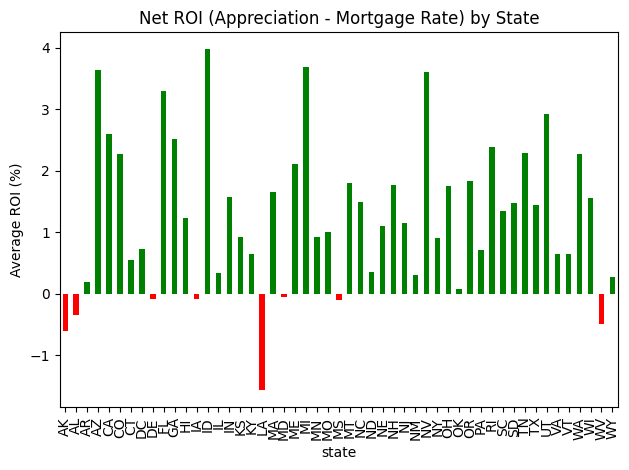

In [38]:
import matplotlib.pyplot as plt
compare["avg_ROI"].plot(kind='bar', color=compare["avg_ROI"].apply(lambda x: 'green' if x>0 else 'red'))
plt.title("Net ROI (Appreciation - Mortgage Rate) by State")
plt.ylabel("Average ROI (%)")
plt.tight_layout()
plt.show()

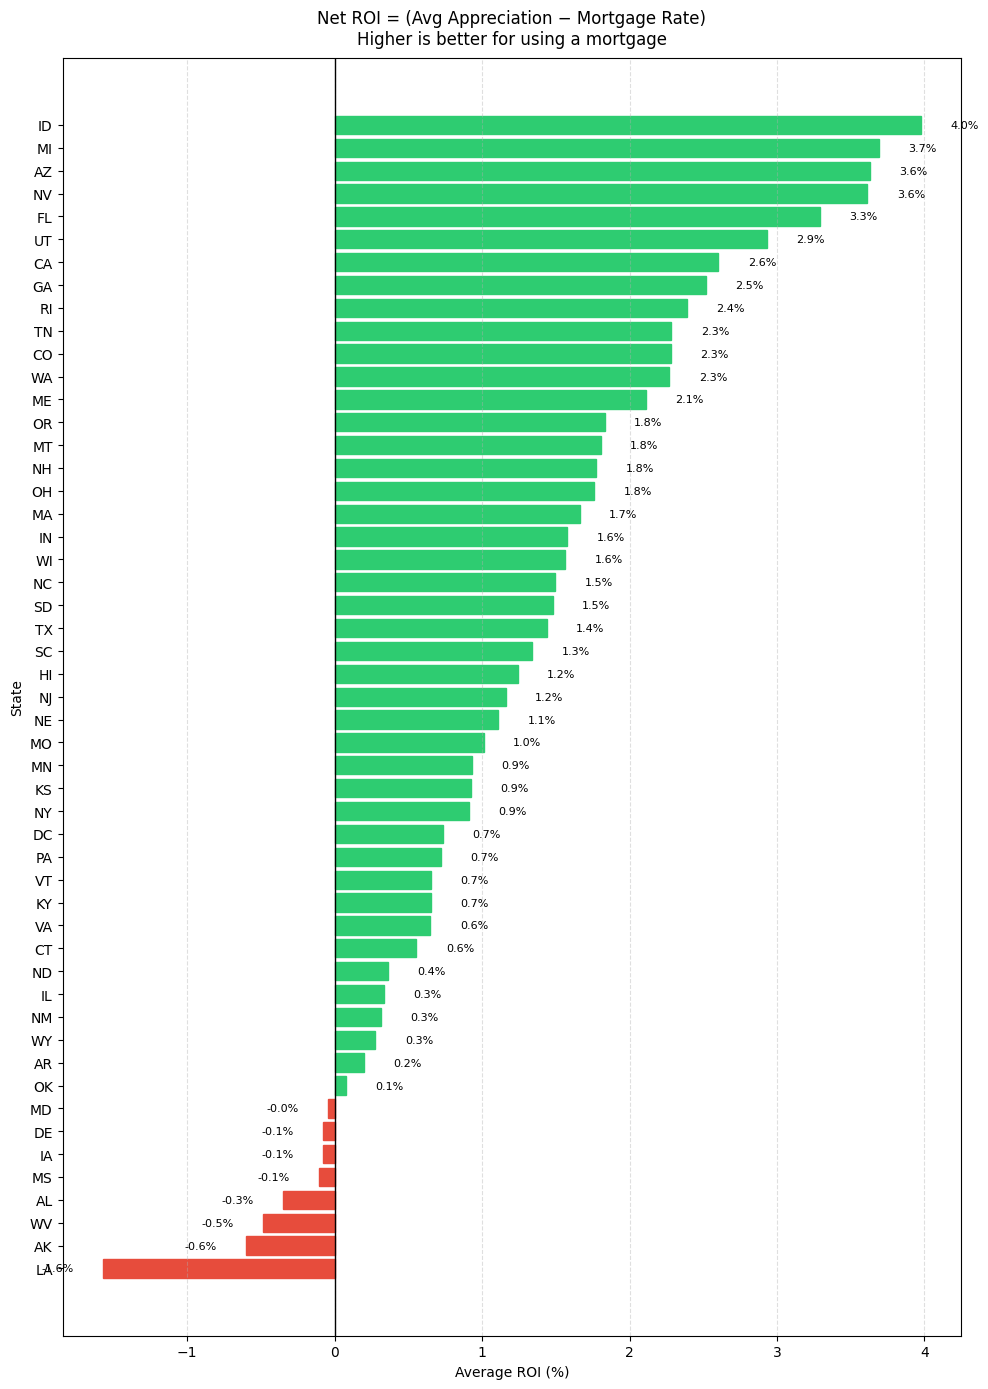

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# sort by ROI
cmp_sorted = compare.sort_values("avg_ROI", ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(cmp_sorted.index, cmp_sorted["avg_ROI"])

# color by sign (green for >0, red for <0)
for b, v in zip(bars, cmp_sorted["avg_ROI"].values):
    b.set_color("#2ecc71" if v > 0 else "#e74c3c")

# add value labels
for b in bars:
    ax.text(b.get_width() + (0.2 if b.get_width()>=0 else -0.2),
            b.get_y() + b.get_height()/2,
            f"{b.get_width():.1f}%", va="center",
            ha="left" if b.get_width()>=0 else "right", fontsize=8)

ax.axvline(0, lw=1, color="black")
ax.set_title("Net ROI = (Avg Appreciation − Mortgage Rate)\nHigher is better for using a mortgage", fontsize=12, pad=10)
ax.set_xlabel("Average ROI (%)")
ax.set_ylabel("State")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

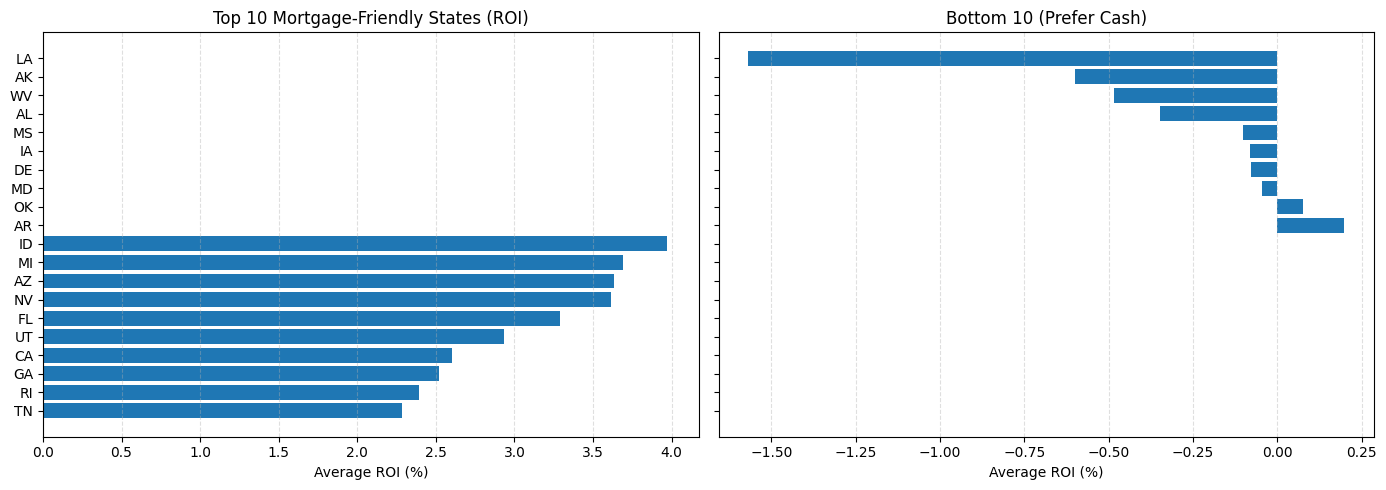

In [40]:
import matplotlib.pyplot as plt

top10 = compare.sort_values("avg_ROI", ascending=False).head(10)
bot10 = compare.sort_values("avg_ROI", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# top 10
axes[0].barh(top10.index[::-1], top10["avg_ROI"][::-1])
axes[0].set_title("Top 10 Mortgage-Friendly States (ROI)")
axes[0].set_xlabel("Average ROI (%)")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# bottom 10
axes[1].barh(bot10.index[::-1], bot10["avg_ROI"][::-1])
axes[1].set_title("Bottom 10 (Prefer Cash)")
axes[1].set_xlabel("Average ROI (%)")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

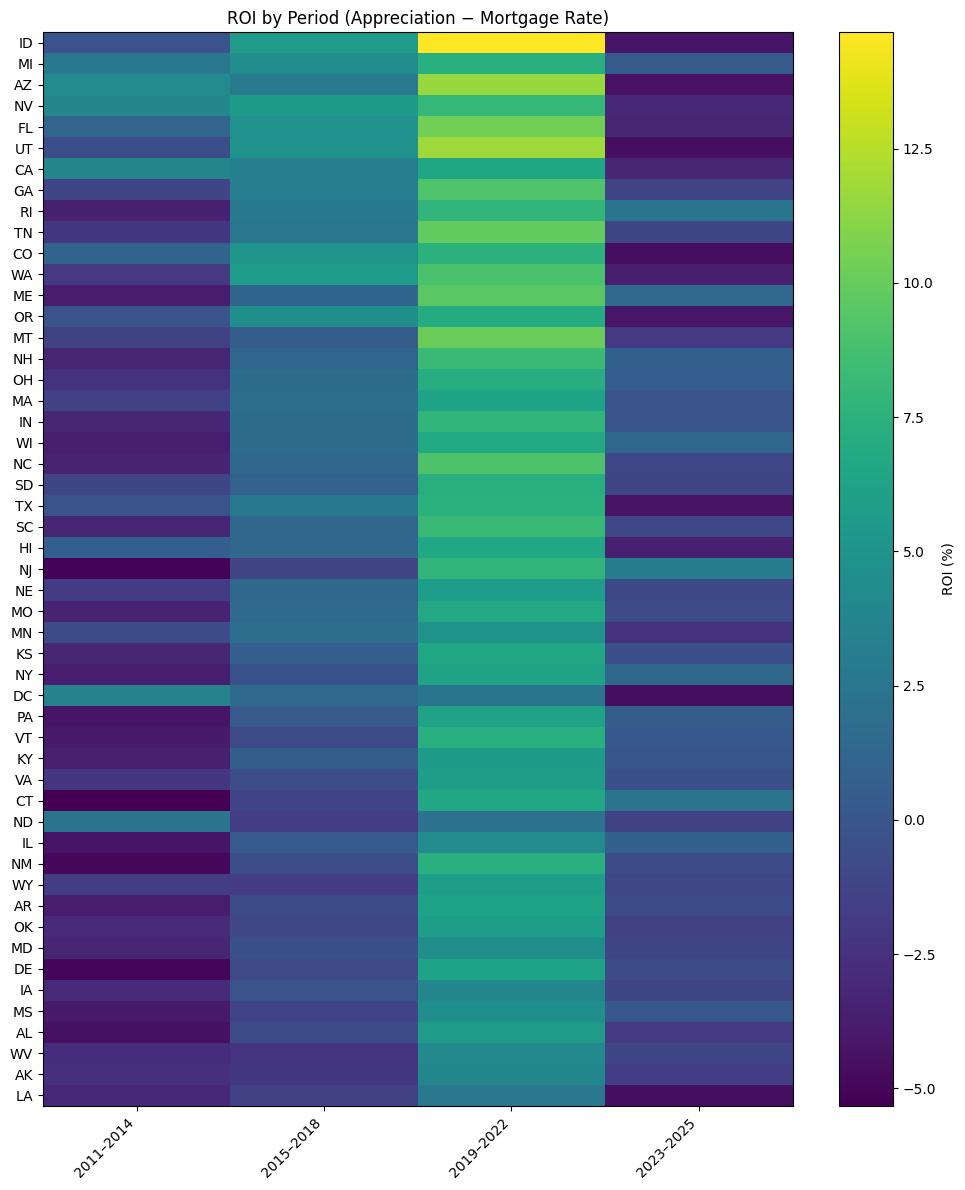

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# build ROI-by-period matrix (appreciation minus period mortgage rate)
mortgage_rates = {
    "2011–2014": 4.2,
    "2015–2018": 4.0,
    "2019–2022": 3.2,
    "2023–2025": 6.5
}

roi_cols = []
for p, r in mortgage_rates.items():
    if p in compare.columns:
        compare[f"ROI_{p}"] = compare[p] - r
        roi_cols.append(f"ROI_{p}")

roi_matrix = compare[roi_cols]
# order rows by overall avg_ROI for readability
roi_matrix = roi_matrix.loc[compare.sort_values("avg_ROI", ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(roi_matrix.values, aspect="auto")

# tick labels
ax.set_yticks(np.arange(len(roi_matrix.index)))
ax.set_yticklabels(roi_matrix.index)
ax.set_xticks(np.arange(len(roi_matrix.columns)))
ax.set_xticklabels([c.replace("ROI_","") for c in roi_matrix.columns], rotation=45, ha="right")

ax.set_title("ROI by Period (Appreciation − Mortgage Rate)")
fig.colorbar(im, ax=ax, label="ROI (%)")
plt.tight_layout()
plt.show()